# Black-Box Neural Network — Friction Torque Identification
## Svaya 6-DOF Cobot | CSIR-CMERI

**Inputs  :** `q` (position, rad), `v` (velocity, rad/s)
**Target  :** `Tf = N·Tm − (−Tj)  =  N·Tm + Tj`
**Joints  :** J1, J2, J3, J5  |  **Gear ratio N = 100**

---
### Code-Flow Overview
```
CSV Load  →  Compute Tf = N*Tm + Tj  →  Feature Matrix X = [q, v]
                        ↓
         Cycle-Aware Train / Test Split  (velocity-target based)
                        ↓
     StandardScaler  →  MLP (tanh layers)  →  EarlyStopping
                        ↓
     Metrics: RMSE / MAE / R²  +  4 Diagnostic Plots per Joint
```

## 0. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)
print("TF version:", tf.__version__)

TF version: 2.21.0


## 1. Global Config

In [2]:
# ── Robot constants ─────────────────────────────────────────────────────────
N  = 100          # gear ratio (motor → joint)
FS = 200          # data logging frequency (Hz)
DT = 1.0 / FS    # 0.005 s per sample

# ── Data folder ──────────────────────────────────────────────────────────────
FOLDER_PATH = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026/Cleaned_Data_By_Joints"

# ── MLP hyper-parameters ─────────────────────────────────────────────────────
HIDDEN_UNITS = [64, 64, 32]   # neurons per hidden layer
ACTIVATION   = "tanh"
OPTIMIZER    = "adam"
BATCH_SIZE   = 512
MAX_EPOCHS   = 1000
PATIENCE     = 20             # EarlyStopping patience

## 2. Helper Functions

In [3]:
# ────────────────────────────────────────────────────────────────────────────
# 2-A  Load CSV, compute friction label
# ────────────────────────────────────────────────────────────────────────────
def load_and_compute_friction(file_path, joint):
    """
    Column naming convention
    ------------------------
    m_t_{j}  : motor torque  Tm   (N·m, motor side)
    jts{j}   : joint torque  Tj   (N·m, joint side, sensor sign convention)
    v{j}     : joint velocity (deg/s)
    q{j}     : joint position (deg)

    Friction label
    --------------
    Tf = N * Tm  -  (-Tj)      <-- double-negative from sensor convention
       = N * Tm  +   Tj
    """
    df    = pd.read_csv(file_path)
    q_deg = df[f"q{joint}"].values
    v_deg = df[f"v{joint}"].values
    tm    = df[f"m_t_{joint}"].values
    tj    = df[f"jts{joint}"].values

    q    = np.deg2rad(q_deg)   # position  → rad
    v    = np.deg2rad(v_deg)   # velocity  → rad/s
    Tf   = N * tm - (-tj)      # = N*tm + tj
    time = np.arange(len(df)) * DT

    return q, v, v_deg, tm, tj, Tf, time


# ────────────────────────────────────────────────────────────────────────────
# 2-B  Cycle-aware train / test split  (velocity-target based)
# ────────────────────────────────────────────────────────────────────────────
def cycle_split(v_deg, joint):
    """
    Detect velocity cycles via zero-crossings, assign each cycle to train
    or test based on its peak velocity.

    Strategy per joint
    ------------------
    J1, J5  : train ~30,36,42 deg/s  |  test ~33,39,45 deg/s  (generalisation)
    J2      : only ~30 deg/s; train first 75%, test last 25%   (temporal split)
    J3      : train ~42 deg/s         |  test ~32 deg/s         (interpolation)
    """
    zc     = np.where(np.diff(np.sign(v_deg)))[0]
    starts = np.insert(zc, 0, 0)
    ends   = np.append(zc, len(v_deg) - 1)

    cycle_list = []
    for s, e in zip(starts, ends):
        if s >= e:
            continue
        seg  = v_deg[s:e]
        peak = np.max(np.abs(seg))
        if peak < 5.0:          # ignore noise / near-zero segments
            continue
        cycle_list.append((s, e, peak))

    train_idx, test_idx = [], []

    if joint == 2:
        sp = int(len(cycle_list) * 0.75)
        for i, (s, e, _) in enumerate(cycle_list):
            (train_idx if i < sp else test_idx).extend(range(s, e))
        t_tr = "Train — first 75% of ~30 deg/s cycles"
        t_te = "Test  — last  25% of ~30 deg/s cycles"

    elif joint == 3:
        for s, e, p in cycle_list:
            if abs(p - 42) <= 3.0:
                train_idx.extend(range(s, e))
            elif abs(p - 32) <= 3.0:
                test_idx.extend(range(s, e))
        t_tr = "Train — ~42 deg/s cycles"
        t_te = "Test  — ~32 deg/s cycles  (interpolation check)"

    else:   # J1, J5
        train_targets = [30, 36, 42]
        test_targets  = [33, 39, 45]
        for s, e, p in cycle_list:
            if   any(abs(p - t) <= 2.5 for t in train_targets):
                train_idx.extend(range(s, e))
            elif any(abs(p - t) <= 2.5 for t in test_targets):
                test_idx.extend(range(s, e))
        t_tr = "Train — ~30, 36, 42 deg/s"
        t_te = "Test  — unseen ~33, 39, 45 deg/s"

    return np.array(train_idx), np.array(test_idx), t_tr, t_te


# ────────────────────────────────────────────────────────────────────────────
# 2-C  Build MLP
# ────────────────────────────────────────────────────────────────────────────
def build_model(n_inputs=2):
    """
    Architecture  :  [q, v]  →  Dense(64,tanh) → Dense(64,tanh) → Dense(32,tanh) → Dense(1)
    Loss          :  MSE
    Optimizer     :  Adam
    """
    layers = [Dense(HIDDEN_UNITS[0], activation=ACTIVATION, input_shape=(n_inputs,))]
    for units in HIDDEN_UNITS[1:]:
        layers.append(Dense(units, activation=ACTIVATION))
    layers.append(Dense(1))   # linear output — regression
    model = Sequential(layers)
    model.compile(optimizer=OPTIMIZER, loss="mse")
    return model


# ────────────────────────────────────────────────────────────────────────────
# 2-D  4-panel diagnostic plots
# ────────────────────────────────────────────────────────────────────────────
def plot_diagnostics(joint, history,
                     v_train_raw, Tf_train,
                     v_test_raw,  y_test, y_pred,
                     title_train, title_test):
    # Panel 1: Training history
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"],     label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("MSE")
    plt.title(f"Joint {joint} — Training History")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # Panel 2: Friction curve in velocity domain
    plt.figure(figsize=(12, 6))
    plt.scatter(v_train_raw, Tf_train,  s=2,  alpha=0.10, color="grey",       label=title_train)
    plt.scatter(v_test_raw,  y_test,    s=15, alpha=0.50, color="dodgerblue", label=f"Actual   | {title_test}")
    plt.scatter(v_test_raw,  y_pred,    s=10, alpha=0.80, color="red",        label=f"Predicted| {title_test}")
    plt.xlabel("Velocity (rad/s)"); plt.ylabel("Friction Torque Tf (N·m)")
    plt.title(f"Joint {joint} — Friction Curve: Actual vs Predicted")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # Panel 3: Parity / scatter plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.4, s=8)
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], "r", lw=1.5, label="Ideal (y=x)")
    plt.xlabel("Actual Tf (N·m)"); plt.ylabel("Predicted Tf (N·m)")
    plt.title(f"Joint {joint} — Parity Plot")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # Panel 4: Residual histogram
    residual = y_test - y_pred
    plt.figure(figsize=(8, 4))
    plt.hist(residual, bins=60, edgecolor="k", linewidth=0.3)
    plt.axvline(0, color="r", linestyle="--", label="Zero error")
    plt.xlabel("Residual (N·m)"); plt.ylabel("Count")
    plt.title(f"Joint {joint} — Residual Distribution")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## 3. Main Loop — Cycle-Split (Velocity Generalisation Test)


  JOINT 1
  Total samples : 47265
  Train         : 26425  (Train — ~30, 36, 42 deg/s)
  Val           : 2937
  Test          : 17461  (Test  — unseen ~33, 39, 45 deg/s)


c:\Users\HP\.conda\envs\csirinternshipenv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465 (25.25 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

  Stopped at epoch 567

  RMSE = 1.0971 N·m
  MAE  = 0.8980  N·m
  R2   = 0.9968


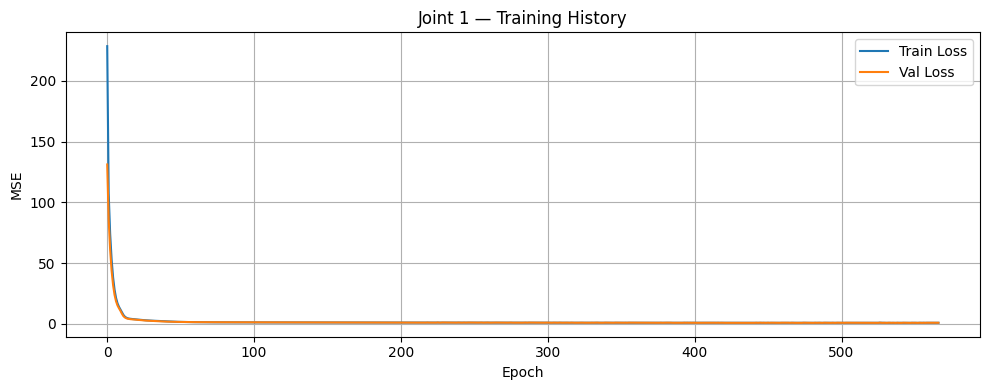

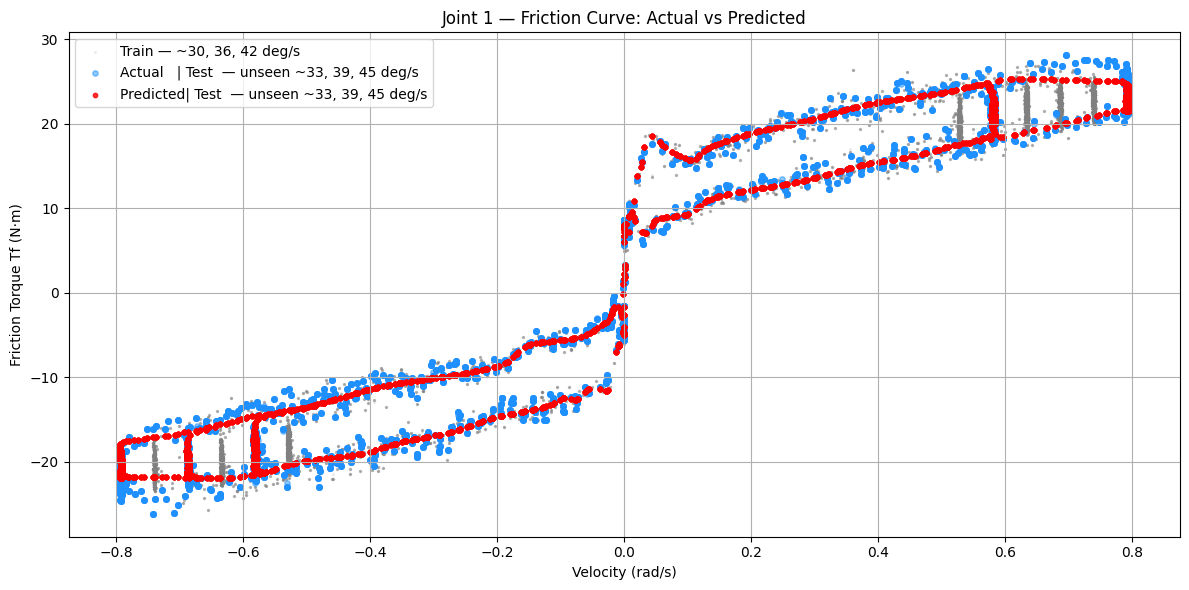

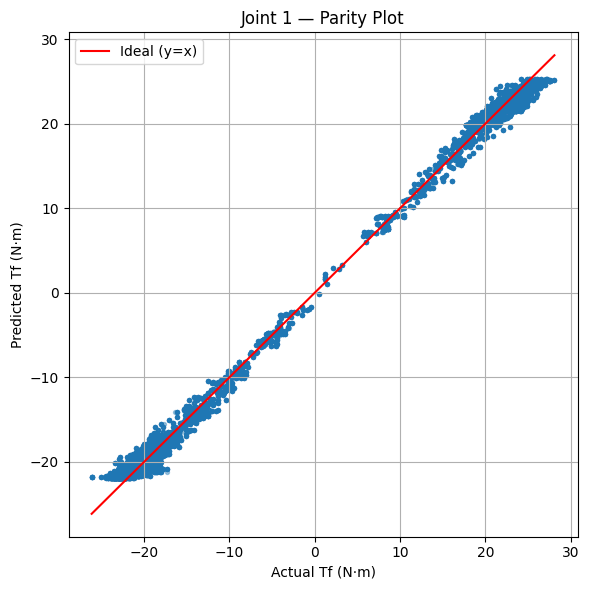

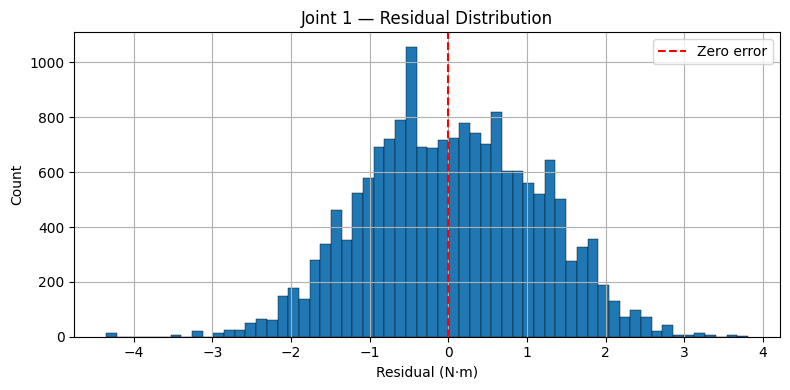


  JOINT 2
  Total samples : 4129
  Train         : 2654  (Train — first 75% of ~30 deg/s cycles)
  Val           : 295
  Test          : 1099  (Test  — last  25% of ~30 deg/s cycles)


c:\Users\HP\.conda\envs\csirinternshipenv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465 (25.25 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

  Stopped at epoch 1000

  RMSE = 2.5451 N·m
  MAE  = 2.0476  N·m
  R2   = 0.9412


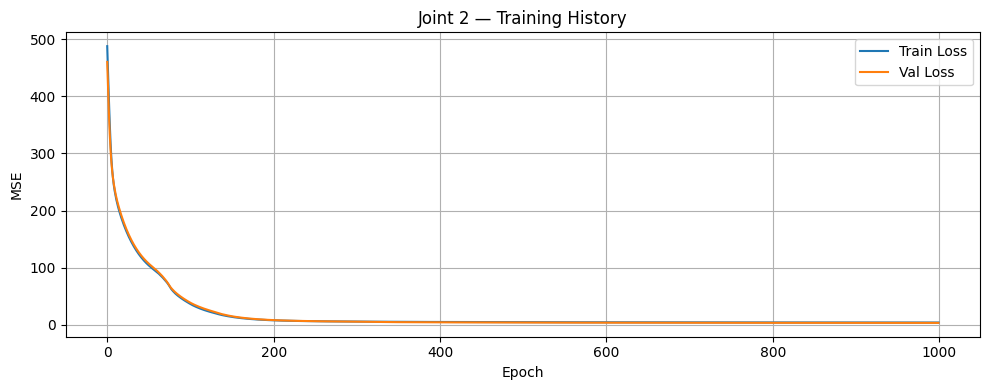

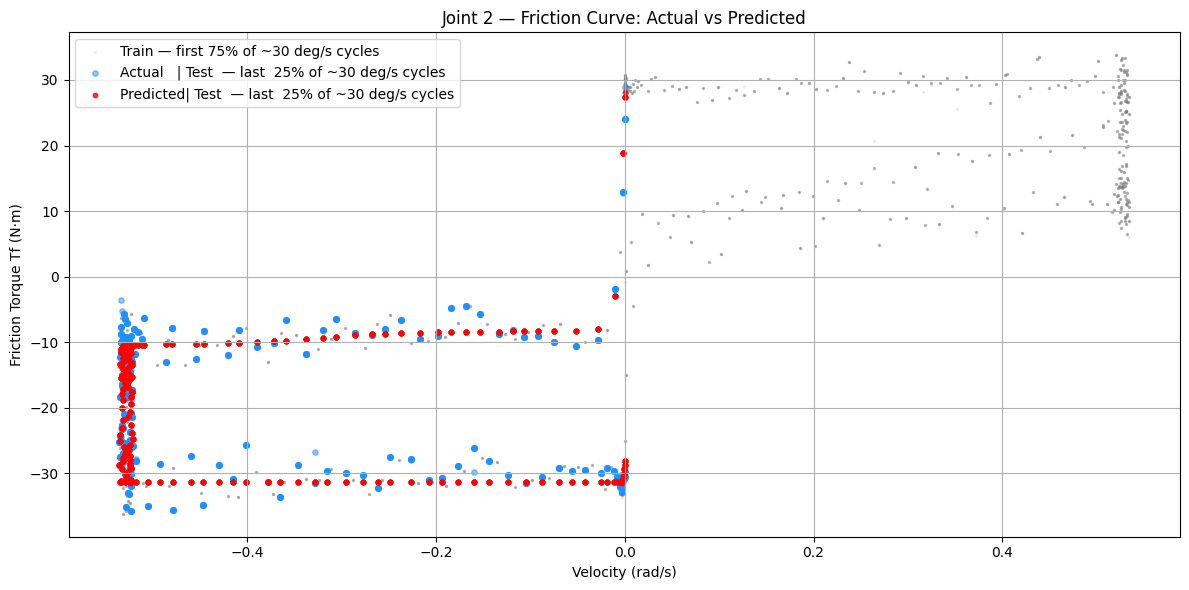

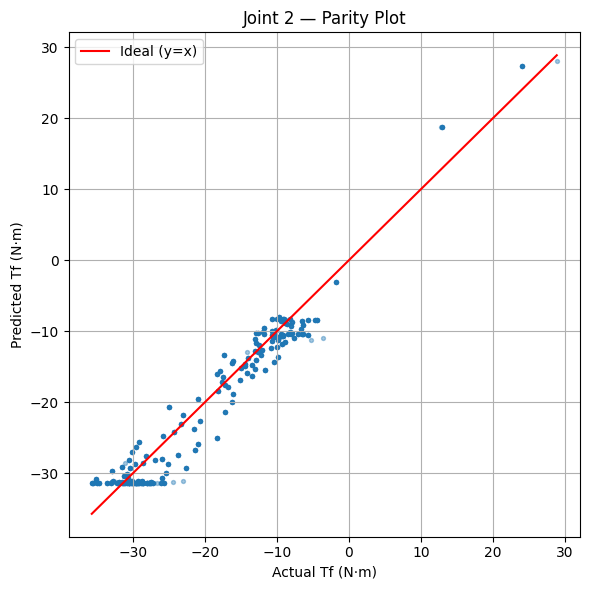

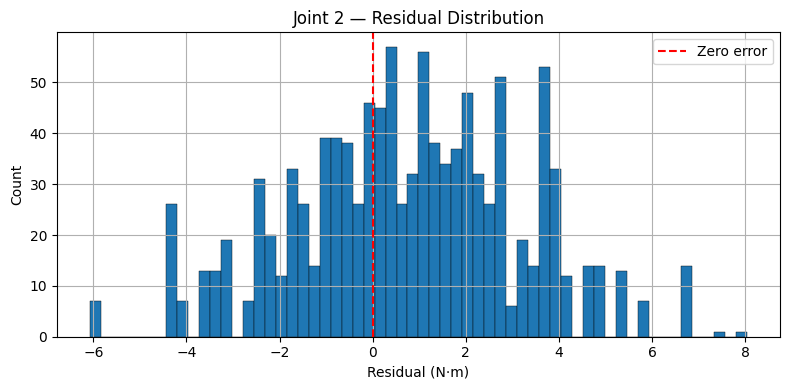


  JOINT 3
  Total samples : 11602
  Train         : 4693  (Train — ~42 deg/s cycles)
  Val           : 522
  Test          : 5600  (Test  — ~32 deg/s cycles  (interpolation check))


c:\Users\HP\.conda\envs\csirinternshipenv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465 (25.25 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

  Stopped at epoch 523

  RMSE = 1.2464 N·m
  MAE  = 1.0165  N·m
  R2   = 0.9866


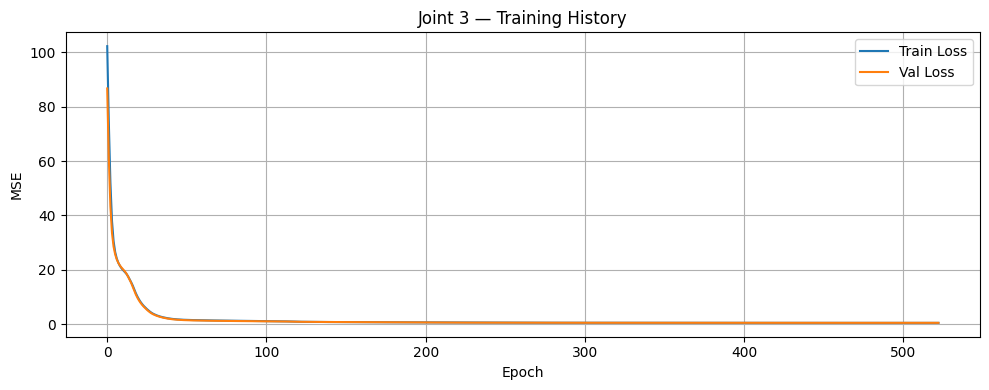

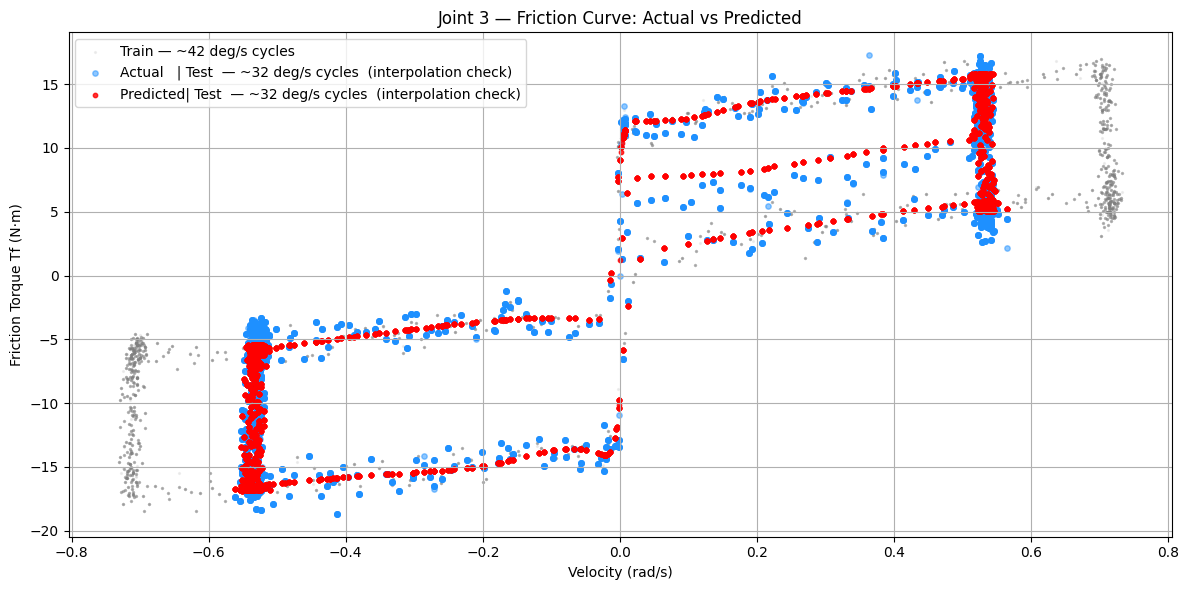

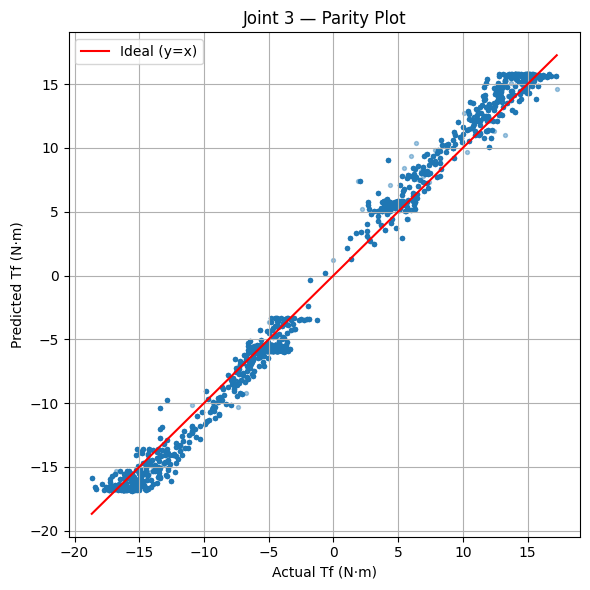

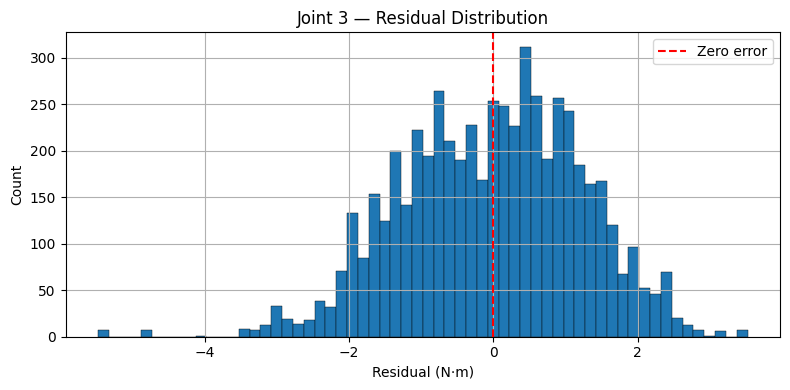


  JOINT 5
  Total samples : 32023
  Train         : 22803  (Train — ~30, 36, 42 deg/s)
  Val           : 2534
  Test          : 4580  (Test  — unseen ~33, 39, 45 deg/s)


c:\Users\HP\.conda\envs\csirinternshipenv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465 (25.25 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

  Stopped at epoch 1000

  RMSE = 0.3716 N·m
  MAE  = 0.2971  N·m
  R2   = 0.9913


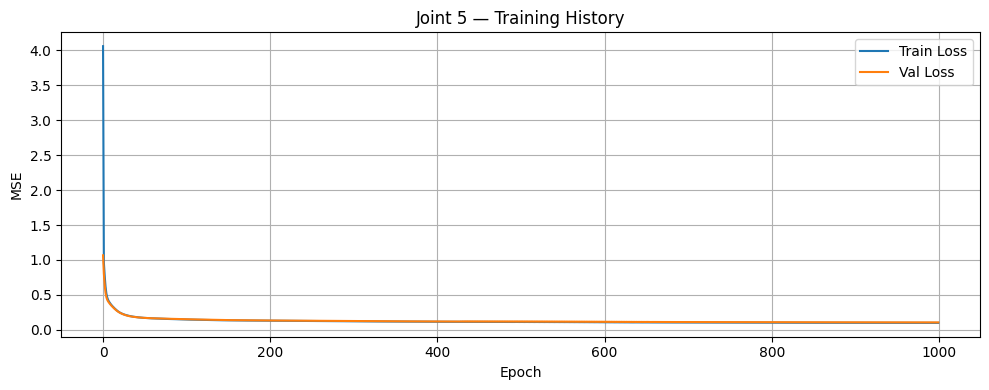

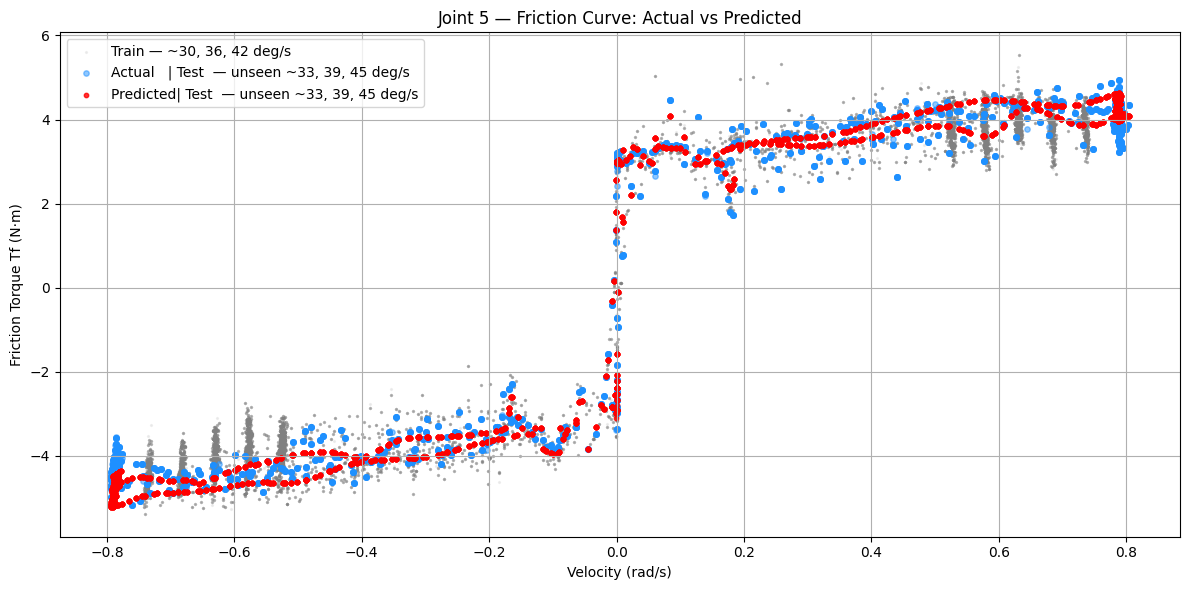

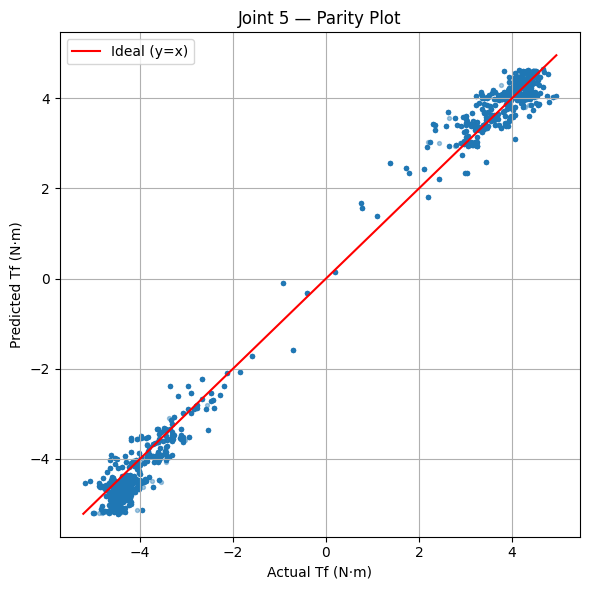

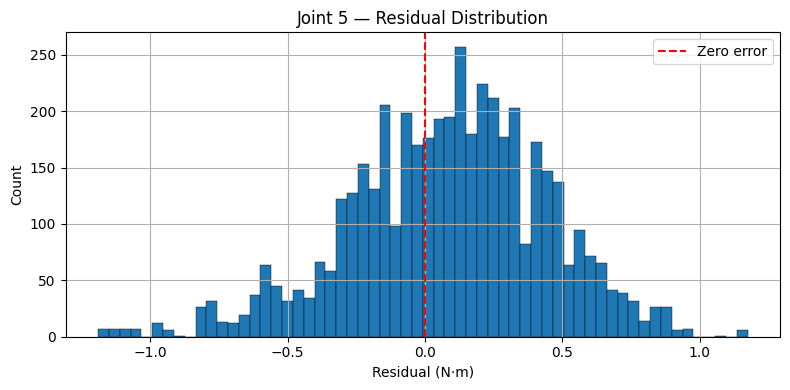

In [5]:
joint_files = {
    1: "Joint_1_Repetitive.csv",
    2: "Joint_2_Repetitive.csv",
    3: "Joint_3_Repetitive.csv",
    5: "Joint_5_Repetitive.csv"
}

results_cycle = {}   # {joint: {RMSE, MAE, R2}}

for joint, filename in joint_files.items():
    print("\n" + "="*80)
    print(f"  JOINT {joint}")
    print("="*80)

    file_path = os.path.join(FOLDER_PATH, filename)
    if not os.path.exists(file_path):
        print(f"  [SKIP] File not found: {file_path}")
        continue

    # ── Step 1: Load data & compute friction label ────────────────────────────
    q, v, v_deg, tm, tj, Tf, time = load_and_compute_friction(file_path, joint)

    # Feature matrix  X = [q (rad),  v (rad/s)]   shape: (n, 2)
    # Target          y = Tf = N*Tm + Tj            shape: (n,)
    X = np.column_stack([q, v])
    y = Tf

    # ── Step 2: Cycle-aware train / test split ────────────────────────────────
    train_idx, test_idx, t_tr, t_te = cycle_split(v_deg, joint)

    if len(train_idx) == 0 or len(test_idx) == 0:
        print(f"  [SKIP] Could not build split for Joint {joint}")
        continue

    X_pool, y_pool = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx],  y[test_idx]

    # Internal 90/10 train-val from pool (shuffled)
    perm    = np.random.permutation(len(X_pool))
    cut     = int(0.90 * len(perm))
    X_train = X_pool[perm[:cut]];  y_train = y_pool[perm[:cut]]
    X_val   = X_pool[perm[cut:]];  y_val   = y_pool[perm[cut:]]

    print(f"  Total samples : {len(X)}")
    print(f"  Train         : {len(X_train)}  ({t_tr})")
    print(f"  Val           : {len(X_val)}")
    print(f"  Test          : {len(X_test)}  ({t_te})")

    # ── Step 3: Feature scaling  (fit ONLY on train) ──────────────────────────
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    # ── Step 4: Build model & train ───────────────────────────────────────────
    model = build_model(n_inputs=2)
    model.summary()

    early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )
    print(f"  Stopped at epoch {len(history.history['loss'])}")

    # ── Step 5: Evaluate on test set ─────────────────────────────────────────
    y_pred = model.predict(X_test, verbose=0).flatten()
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)

    print(f"\n  RMSE = {rmse:.4f} N·m")
    print(f"  MAE  = {mae:.4f}  N·m")
    print(f"  R2   = {r2:.4f}")
    results_cycle[joint] = dict(RMSE=rmse, MAE=mae, R2=r2)

    # ── Step 6: Diagnostic plots ──────────────────────────────────────────────
    v_test_plot  = scaler.inverse_transform(X_test)[:, 1]   # rad/s, unscaled
    v_train_plot = X_pool[:, 1]                               # was never scaled

    plot_diagnostics(joint, history,
                     v_train_plot, y_pool,
                     v_test_plot,  y_test, y_pred,
                     t_tr, t_te)

## 4. Summary Table

In [7]:
print("\n" + "="*65)
print("CYCLE-SPLIT  (honest velocity-generalisation metric)")
print("="*65)
print(f"  {'Joint':6} | {'RMSE':>10} | {'MAE':>10} | {'R2':>8}")
print("-"*45)
for j, m in results_cycle.items():
    print(f"  J{j}    | {m['RMSE']:>10.4f} | {m['MAE']:>10.4f} | {m['R2']:>8.4f}")

print("\n" + "="*65)
print("RANDOM-SPLIT  (inflated R2 — hysteresis leakage, do NOT report)")
print("="*65)
print(f"  {'Joint':6} | {'RMSE':>10} | {'MAE':>10} | {'R2':>8}")
print("-"*45)
for j, m in results_random.items():
    print(f"  J{j}    | {m['RMSE']:>10.4f} | {m['MAE']:>10.4f} | {m['R2']:>8.4f}")


CYCLE-SPLIT  (honest velocity-generalisation metric)
  Joint  |       RMSE |        MAE |       R2
---------------------------------------------
  J1    |     1.0971 |     0.8980 |   0.9968
  J2    |     2.5451 |     2.0476 |   0.9412
  J3    |     1.2464 |     1.0165 |   0.9866
  J5    |     0.3716 |     0.2971 |   0.9913

RANDOM-SPLIT  (inflated R2 — hysteresis leakage, do NOT report)
  Joint  |       RMSE |        MAE |       R2
---------------------------------------------
  J1    |     0.9516 |     0.7548 |   0.9975
  J2    |     2.1706 |     1.7393 |   0.9906
  J3    |     0.8404 |     0.6012 |   0.9940
  J5    |     0.3719 |     0.2687 |   0.9904
